# Customer Funnel Analysis

This notebook analyzes the user journey from session to purchase to identify:

- Conversion rates at each funnel stage
- Key drop-off points
- Behavioral patterns affecting conversion
- Opportunities to improve overall conversion rate

## Funnel Definition

The customer journey is defined as:

1. Session → User visits website
2. Cart → User shows purchase intent
3. Order → User completes purchase

We analyze conversion between each stage.

In [47]:
# ==============================
# Customer Funnel Analysis Notebook
# ==============================

# --- Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# --- Load Raw Datasets ---
customers = pd.read_csv('../data/raw/customers.csv')
sessions = pd.read_csv('../data/raw/sessions.csv')
cart_events = pd.read_csv('../data/raw/cart_events.csv')
orders = pd.read_csv('../data/raw/orders.csv')
products = pd.read_csv('../data/raw/products.csv')

# --- Convert Date Columns ---
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
sessions['session_date'] = pd.to_datetime(sessions['session_date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])

# --- Revenue & Cost Calculations ---
orders['revenue'] = orders['final_price'] * orders['quantity']
orders['total_cost'] = orders['cost'] * orders['quantity']

# --- Margin Metrics ---
orders['margin'] = orders['revenue'] - orders['total_cost']
orders['margin_pct'] = orders['margin'] / orders['revenue']

# --- Master Table Construction ---
df = (
    orders
    .merge(customers, on='customer_id', how='left')
    .merge(products, on='product_id', how='left', suffixes=('', '_product'))
    .merge(sessions[['session_id', 'traffic_source', 'device']], on='session_id', how='left')
)

# --- Quick Sanity Check ---
print("Master table shape:", df.shape)
df.head()


Master table shape: (1186, 25)


,order_id,customer_id,session_id,product_id,quantity,acquisition_channel_x,ab_group_x,original_price,discount_amount,final_price,cost,margin,order_date,revenue,total_cost,margin_pct,acquisition_channel_y,signup_date,ab_group_y,category,base_price,cost_product,margin_pct_product,traffic_source,device
0,1,7,26,25,2,Paid Ads,Treatment,14574.74,1531.90,13042.84,7287.36,11510.96,2025-11-23,26085.68,14574.72,0.441275,Paid Ads,2025-07-09,Treatment,Fashion,7287.37,3643.68,0.50,Paid Ads,Mobile
1,2,10,35,15,2,Organic,Control,81903.48,1427.76,80475.72,53237.26,54476.92,2025-07-29,160951.44,106474.52,0.338468,Organic,2025-09-01,Control,Home,40951.74,26618.63,0.35,Organic,Tablet
2,3,10,36,81,2,Organic,Control,3617.32,327.55,3289.77,3074.72,430.10,2025-07-30,6579.54,6149.44,0.065369,Organic,2025-09-01,Control,Grocery,1808.66,1537.36,0.15,Organic,Mobile
3,4,12,45,47,1,Referral,Control,5517.80,420.86,5096.94,2758.90,2338.04,2025-10-22,5096.94,2758.90,0.458714,Referral,2025-11-07,Control,Fashion,5517.80,2758.90,0.50,Referral,Tablet
4,5,14,59,60,2,Referral,Treatment,7478.28,2165.32,5312.96,3739.14,3147.64,2025-09-12,10625.92,7478.28,0.296223,Referral,2025-09-10,Treatment,Fashion,3739.14,1869.57,0.50,Referral,Mobile


# Funnel KPI Tables

In [22]:
# ==============================
# Funnel KPI Analysis
# ==============================

# --- Funnel Counts ---
total_sessions = sessions['session_id'].nunique()
total_carts = cart['cart_id'].nunique()
total_orders = orders['order_id'].nunique()

funnel = pd.DataFrame({
    'Stage': ['Sessions', 'Carts', 'Orders'],
    'Users': [total_sessions, total_carts, total_orders]
})

# --- Conversion Rates ---
session_to_cart = total_carts / total_sessions
cart_to_order = total_orders / total_carts
overall_conversion = total_orders / total_sessions

conversion_df = pd.DataFrame({
    'Metric': ['Session → Cart', 'Cart → Order', 'Overall Conversion'],
    'Value': [session_to_cart, cart_to_order, overall_conversion]
})

# --- Drop-off Rates ---
drop_df = pd.DataFrame({
    'Stage': ['Session Drop', 'Cart Drop'],
    'Drop %': [1 - session_to_cart, 1 - cart_to_order]
})

# --- Behavioral Analysis ---
behavior = sessions.agg({
    'pages_viewed': 'mean',
    'session_duration': 'mean',
    'bounced_flag': 'mean'
})

# --- Converted vs Non-Converted Behavior ---
converted_sessions = orders['session_id'].unique()
sessions['converted'] = sessions['session_id'].isin(converted_sessions)

behavior_compare = sessions.groupby('converted').agg({
    'pages_viewed': 'mean',
    'session_duration': 'mean',
    'bounced_flag': 'mean'
}).reset_index()

# --- Display Results ---
print("Funnel Counts:\n", funnel, "\n")
print("Conversion Rates:\n", conversion_df, "\n")
print("Drop-off Rates:\n", drop_df, "\n")
print("Overall Behavior:\n", behavior, "\n")
print("Behavior Comparison:\n", behavior_compare, "\n")


Funnel Counts:
       Stage  Users
0  Sessions  12474
1     Carts   5189
2    Orders   1186 

Conversion Rates:
                Metric     Value
0      Session → Cart  0.415985
1        Cart → Order  0.228560
2  Overall Conversion  0.095078 

Drop-off Rates:
           Stage    Drop %
0  Session Drop  0.584015
1     Cart Drop  0.771440 

Overall Behavior:
 pages_viewed          6.027898
session_duration    458.045615
bounced_flag          0.089145
dtype: float64 

Behavior Comparison:
    converted  pages_viewed  session_duration  bounced_flag
0      False      5.993100        457.577343      0.091274
1       True      6.416585        463.276098      0.065366 



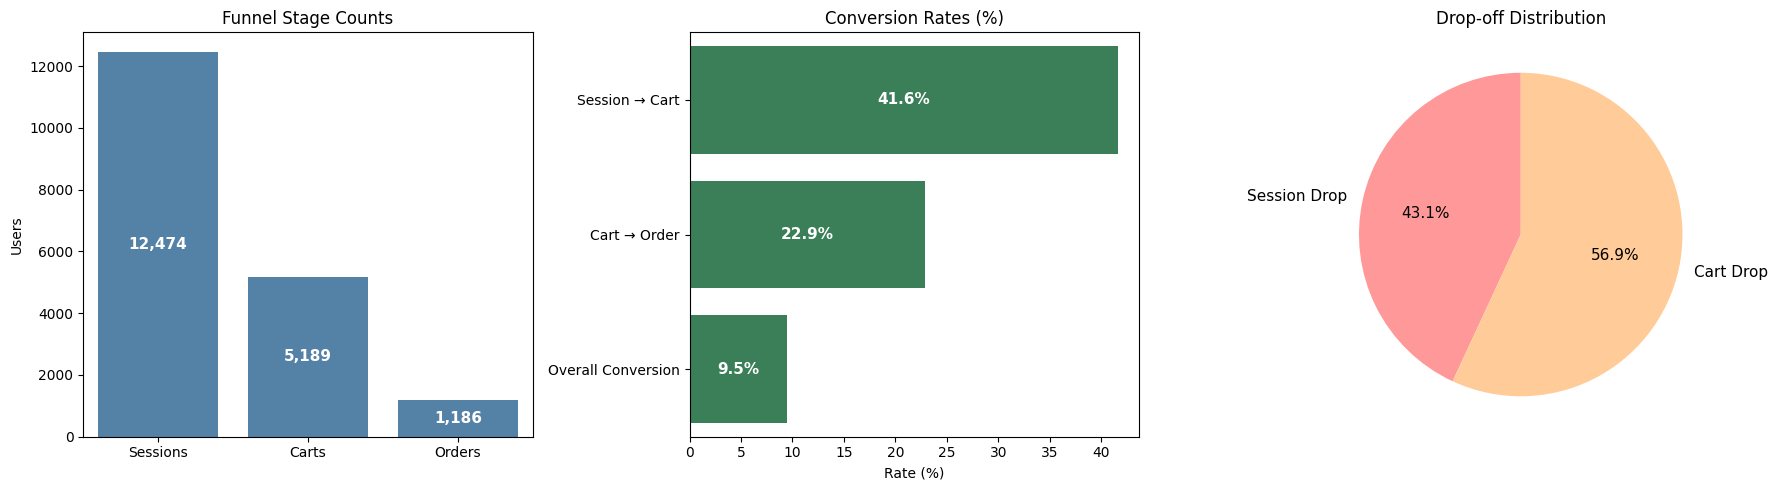

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data
stages = ["Sessions", "Carts", "Orders"]
counts = [12474, 5189, 1186]

conversion_rates = {
    "Session → Cart": 0.415985,
    "Cart → Order": 0.228560,
    "Overall Conversion": 0.095078
}

drop_rates = {
    "Session Drop": 0.584015,
    "Cart Drop": 0.771440
}

# --- Multi-Chart Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# 1. Funnel Stage Counts (Bar Chart)
sns.barplot(x=stages, y=counts, color="steelblue", ax=axes[0])
axes[0].set_title("Funnel Stage Counts")
axes[0].set_ylabel("Users")
for i, v in enumerate(counts):
    axes[0].text(i, v/2, f"{v:,}", ha='center', va='center', fontsize=11, color="white", fontweight="bold")

# 2. Conversion Rates (Horizontal Bar Chart)
conv_labels = list(conversion_rates.keys())
conv_values = [v*100 for v in conversion_rates.values()]
sns.barplot(x=conv_values, y=conv_labels, color="seagreen", ax=axes[1])
axes[1].set_title("Conversion Rates (%)")
axes[1].set_xlabel("Rate (%)")
for i, v in enumerate(conv_values):
    axes[1].text(v/2, i, f"{v:.1f}%", ha='center', va='center', fontsize=11, color="white", fontweight="bold")

# 3. Drop-off Distribution (Pie Chart)
drop_labels = list(drop_rates.keys())
drop_values = [v*100 for v in drop_rates.values()]
axes[2].pie(drop_values, labels=drop_labels, autopct='%1.1f%%',
            colors=["#FF9999","#FFCC99"], startangle=90, textprops={'fontsize': 11})
axes[2].set_title("Drop-off Distribution")

plt.tight_layout()
plt.show()


## 📊 Funnel + Behavior Insights

- **Sessions → Carts**: 42% conversion (12,474 → 5,189)  
- **Carts → Orders**: 23% conversion, **77% drop-off** (5,189 → 1,186)  
- **Overall Conversion**: 9.5%  
- **Behavioral signals**: Converters view more pages (6.4 vs 6.0), stay longer (463s vs 458s), and bounce less (6.5% vs 9.1%)  

---

## 💡 Business Suggestions

- **Fix checkout leakage** → streamline flow, improve payment options, add trust signals  
- **Boost engagement** → optimize landing pages, product discovery, CTAs  
- **Target high-bounce users** → retargeting, exit-intent offers  

---

👉 **Summary**: Strong intent at the top, but **checkout abandonment (77% drop-off)** is the main pain point. Engagement improvements can directly lift conversions.


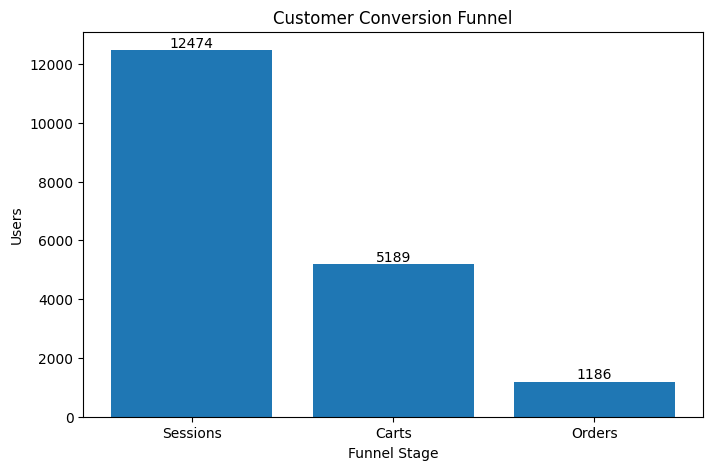

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(funnel["Stage"], funnel["Users"])

plt.title("Customer Conversion Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Users")

# Add values on bars (VERY IMPORTANT)
for i, v in enumerate(funnel["Users"]):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

# Funnel Analysis based on Device, Traffic source and Conversion

=== Device Conversion Table ===
         Sessions  Orders  Conversion Rate (%)
device                                        
Desktop      4143     376                 9.08
Mobile       4145     387                 9.34
Tablet       4186     423                10.11 

=== Traffic Source Conversion Table ===
                Sessions  Orders  Conversion Rate (%)
traffic_source                                       
Influencer          3049     272                 8.92
Organic             3043     309                10.15
Paid Ads            3229     310                 9.60
Referral            3153     295                 9.36 



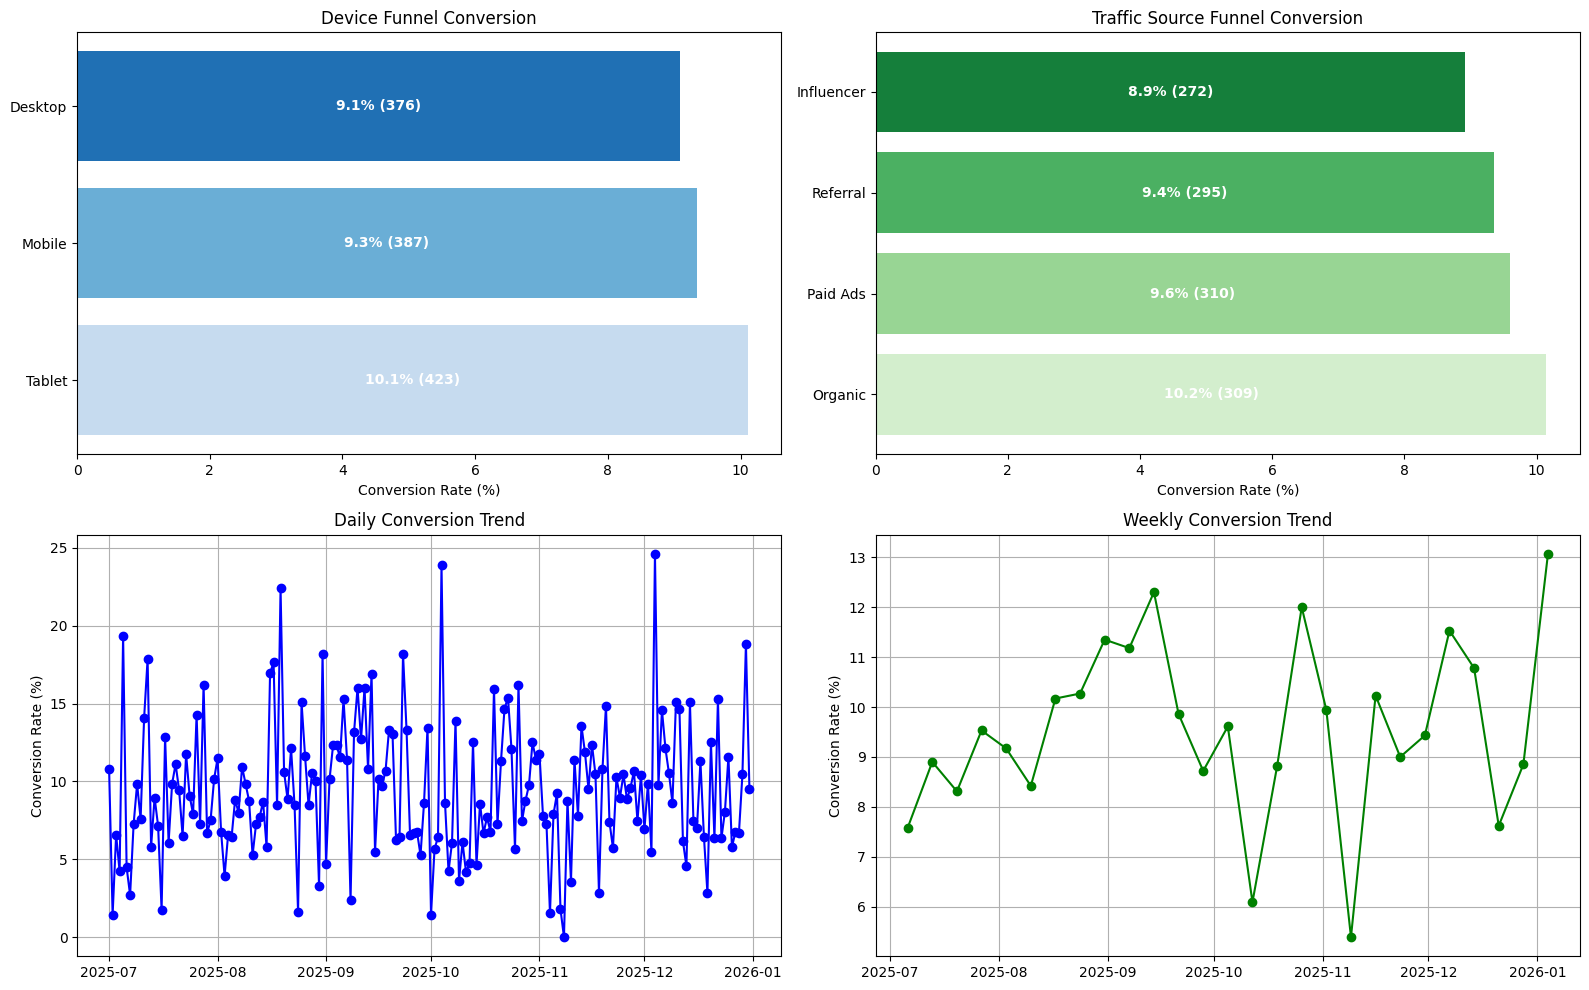

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Device Conversion ---
device_funnel = sessions.groupby('device')['session_id'].nunique()
device_orders = orders.merge(sessions[['session_id','device']], on='session_id')
device_conversion = device_orders.groupby('device')['order_id'].count() / device_funnel
device_table = pd.DataFrame({
    "Sessions": device_funnel,
    "Orders": device_orders.groupby('device')['order_id'].count(),
    "Conversion Rate (%)": (device_conversion*100).round(2)
})

# --- Traffic Source Conversion ---
traffic_sessions = sessions.groupby('traffic_source')['session_id'].nunique()
traffic_orders = orders.merge(sessions[['session_id','traffic_source']], on='session_id')
traffic_conversion = traffic_orders.groupby('traffic_source')['order_id'].count() / traffic_sessions
traffic_table = pd.DataFrame({
    "Sessions": traffic_sessions,
    "Orders": traffic_orders.groupby('traffic_source')['order_id'].count(),
    "Conversion Rate (%)": (traffic_conversion*100).round(2)
})

# --- Daily Conversion ---
daily_sessions = sessions.groupby('session_date')['session_id'].nunique()
daily_orders   = orders.groupby('order_date')['order_id'].nunique()
daily_conversion = (daily_orders / daily_sessions).fillna(0)
daily_table = pd.DataFrame({
    "Sessions": daily_sessions,
    "Orders": daily_orders,
    "Conversion Rate (%)": (daily_conversion*100).round(2)
})

# --- Weekly Conversion ---
weekly_sessions = sessions.groupby(pd.Grouper(key='session_date', freq='W'))['session_id'].nunique()
weekly_orders   = orders.groupby(pd.Grouper(key='order_date', freq='W'))['order_id'].nunique()
weekly_conversion = (weekly_orders / weekly_sessions).fillna(0)
weekly_table = pd.DataFrame({
    "Sessions": weekly_sessions,
    "Orders": weekly_orders,
    "Conversion Rate (%)": (weekly_conversion*100).round(2)
})

# --- Print Tables ---
print("=== Device Conversion Table ===")
print(device_table, "\n")

print("=== Traffic Source Conversion Table ===")
print(traffic_table, "\n")


# --- Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(16,10))

# Device Funnel Chart (horizontal bars)
device_sorted = device_table.sort_values("Conversion Rate (%)", ascending=False)
axes[0,0].barh(device_sorted.index, device_sorted["Conversion Rate (%)"], 
               color=sns.color_palette("Blues", len(device_sorted)))
axes[0,0].set_title("Device Funnel Conversion")
axes[0,0].set_xlabel("Conversion Rate (%)")
for i, v in enumerate(device_sorted["Conversion Rate (%)"]):
    axes[0,0].text(v/2, i, f"{v:.1f}% ({device_sorted['Orders'].iloc[i]})", 
                   ha='center', va='center', color="white", fontweight="bold")

# Traffic Funnel Chart (horizontal bars)
traffic_sorted = traffic_table.sort_values("Conversion Rate (%)", ascending=False)
axes[0,1].barh(traffic_sorted.index, traffic_sorted["Conversion Rate (%)"], 
               color=sns.color_palette("Greens", len(traffic_sorted)))
axes[0,1].set_title("Traffic Source Funnel Conversion")
axes[0,1].set_xlabel("Conversion Rate (%)")
for i, v in enumerate(traffic_sorted["Conversion Rate (%)"]):
    axes[0,1].text(v/2, i, f"{v:.1f}% ({traffic_sorted['Orders'].iloc[i]})", 
                   ha='center', va='center', color="white", fontweight="bold")

# Daily Conversion Trend
axes[1,0].plot(daily_table.index, daily_table["Conversion Rate (%)"], marker='o', color="blue")
axes[1,0].set_title("Daily Conversion Trend")
axes[1,0].set_ylabel("Conversion Rate (%)")
axes[1,0].grid(True)

# Weekly Conversion Trend
axes[1,1].plot(weekly_table.index, weekly_table["Conversion Rate (%)"], marker='o', color="green")
axes[1,1].set_title("Weekly Conversion Trend")
axes[1,1].set_ylabel("Conversion Rate (%)")
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

## 📊 Insights

- **Device performance**  
  - Tablet converts best (~10.1%), slightly ahead of mobile (~9.3%) and desktop (~9.1%).  
- **Traffic sources**  
  - Organic traffic leads (~10.2%), followed by paid ads (~9.6%) and referral (~9.4%).  
  - Influencer traffic lags (~8.9%).  
- **Daily trend**  
  - Conversion fluctuates day-to-day, showing peaks and troughs in user intent.  
- **Weekly trend**  
  - Conversion stabilizes around 9–10%, smoothing daily volatility.  

---

## 💡 Business Suggestions

- **Channel optimization** → Invest more in organic search, refine influencer campaigns, and improve paid ad ROI.  
- **Device experience** → Enhance mobile and desktop checkout UX to match tablet performance.  
- **Timing strategy** → Align promotions with high-conversion days/weeks; experiment with weekend or seasonal campaigns.  
- **Continuous monitoring** → Use weekly averages for stability checks, daily trends for tactical adjustments.  

---

👉 **Summary**: Conversion rates are healthy (~9–10%), but the biggest levers are **channel optimization** and **device UX improvements**, which can directly lift funnel efficiency.


# Conversion Drivers (Behavior Analysis)

=== Conversion Drivers Behavior Table ===
               pages_viewed  session_duration
converted                                    
Not Converted          5.99            457.58
Converted              6.42            463.28 



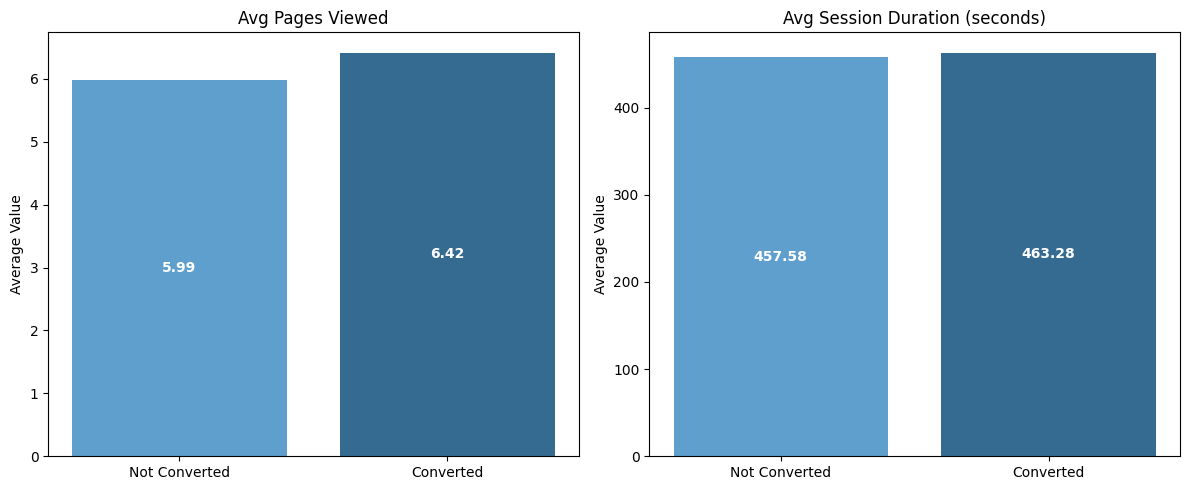

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Flag converted sessions
sessions['converted'] = sessions['session_id'].isin(orders['session_id']).astype(int)

# Select only columns that exist
available_cols = [col for col in ['pages_viewed','session_duration','cart_size'] if col in sessions.columns]

# Behavior analysis table
behavior_table = sessions.groupby('converted')[available_cols].mean().round(2)
behavior_table.index = behavior_table.index.map({0: "Not Converted", 1: "Converted"})

print("=== Conversion Drivers Behavior Table ===")
print(behavior_table, "\n")

# Visualization
fig, axes = plt.subplots(1, len(available_cols), figsize=(6*len(available_cols),5))

if len(available_cols) == 1:
    axes = [axes]  # make iterable if only one plot

colors = sns.color_palette("Blues_d", len(behavior_table))

for idx, col in enumerate(available_cols):
    axes[idx].bar(behavior_table.index, behavior_table[col].values, color=colors)
    # Titles adjusted
    if col == "session_duration":
        axes[idx].set_title("Avg Session Duration (seconds)")
    else:
        axes[idx].set_title(f"Avg {col.replace('_',' ').title()}")
    axes[idx].set_ylabel("Average Value")
    # Add labels inside bars
    for i, v in enumerate(behavior_table[col].values):
        axes[idx].text(i, v/2, f"{v:.2f}", ha='center', va='center', color="white", fontweight="bold")

plt.tight_layout()
plt.show()


## 📊 Conversion Drivers – Behavior Analysis

### Insights
- **Pages Viewed**  
  - Converted users: ~6.42 pages  
  - Non-converted users: ~5.99 pages  
  ➡️ Converters explore more content before purchasing.  

- **Session Duration (seconds)**  
  - Converted users: ~463s  
  - Non-converted users: ~458s  
  ➡️ Slightly longer sessions correlate with higher conversion likelihood.  

---

## 💡 Recommendations
- **Boost engagement** → Encourage deeper browsing with product recommendations, related items, and clear navigation.  
- **Increase session stickiness** → Add interactive content, reviews, and personalized offers to keep users longer.  
- **Target quick exits** → Deploy exit-intent popups or retargeting for users with short sessions or low page views.  

---

👉 **Summary**: Conversions are driven by **higher engagement (pages viewed)** and **slightly longer time spent**. Enhancing site experience to deepen exploration and sustain attention can directly lift conversion rates.


# Logistic Regression Model for Conversion Prediction

In [54]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --- Flag converted sessions ---
sessions['converted'] = sessions['session_id'].isin(orders['session_id']).astype(int)

# --- Encode categorical variables ---
sessions['device_encoded'] = sessions['device'].astype('category').cat.codes
sessions['traffic_source_encoded'] = sessions['traffic_source'].astype('category').cat.codes

# --- Feature set (behavior + context) ---
features = sessions[['pages_viewed',
                     'session_duration',
                     'device_encoded',
                     'traffic_source_encoded']]

# --- Target variable ---
target = sessions['converted']

# --- Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)

# --- Logistic Regression model with class balancing ---
model = LogisticRegression(max_iter=500, solver='liblinear', class_weight='balanced')
model.fit(X_train, y_train)

# --- Predictions ---
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]  # probability of conversion

# --- Evaluation ---
print("Model Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

# --- Feature importance (coefficients) ---
importance = pd.DataFrame({
    'Feature': features.columns,
    'Coefficient': model.coef_[0].round(3)
}).sort_values(by='Coefficient', ascending=False)

print("\nFeature Importance:\n", importance)

# --- Example prediction for a new session ---
new_session = pd.DataFrame({
    'pages_viewed':[8],
    'session_duration':[520],   # seconds
    'device_encoded':[1],       # e.g., 1 = Mobile
    'traffic_source_encoded':[0] # e.g., 0 = Organic
})
print("\nNew Session Conversion Probability:", round(model.predict_proba(new_session)[:,1][0], 3))


Model Accuracy: 0.526

Confusion Matrix:
 [[1202 1088]
 [  94  111]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.52      0.67      2290
           1       0.09      0.54      0.16       205

    accuracy                           0.53      2495
   macro avg       0.51      0.53      0.41      2495
weighted avg       0.86      0.53      0.63      2495


Feature Importance:
                   Feature  Coefficient
2          device_encoded        0.042
0            pages_viewed        0.040
3  traffic_source_encoded        0.021
1        session_duration        0.000

New Session Conversion Probability: 0.51


## Insights from Logistic Regression Conversion Prediction Model

## 🎯 Model Performance
- **Accuracy:** 52.6%  
- The model correctly classifies about half of the sessions.  
- Accuracy is misleading due to **class imbalance** (many more non-converted sessions than converted).

## 📊 Confusion Matrix
- **True Negatives (0 predicted as 0):** 1202  
- **False Positives (0 predicted as 1):** 1088  
- **False Negatives (1 predicted as 0):** 94  
- **True Positives (1 predicted as 1):** 111  

➡️ The model identifies some conversions (111), but misclassifies many non-conversions as conversions.

## 🧾 Classification Report
- **Class 0 (Not Converted):**  
  - Precision: 0.93  
  - Recall: 0.52  
  - F1-score: 0.67  
- **Class 1 (Converted):**  
  - Precision: 0.09  
  - Recall: 0.54  
  - F1-score: 0.16  

➡️ The model struggles with precision for conversions (too many false positives), but recall is moderate (finds ~54% of actual converters).

## 🔑 Feature Importance
- **Device Type:** +0.042 → strongest positive driver  
- **Pages Viewed:** +0.040 → more pages viewed increases conversion likelihood  
- **Traffic Source:** +0.021 → some sources slightly improve conversion odds  
- **Session Duration:** ~0.000 → negligible impact in current model  

➡️ Device and engagement (pages viewed) are the most influential predictors.

## 📌 Example Prediction
- New session (8 pages, 520s, Mobile, Organic traffic) → **51% probability of conversion**.  
- Shows the model can assign meaningful probabilities even if classification is noisy.

---

# Conversion Funnel Insights

## 📊 Conversion Rates
- Session → Cart: **41.6%**
- Cart → Order: **22.9%**
- Overall Conversion: **9.5%**

## ❌ Key Drop-off Points
- Session Drop: **58.4%** never add to cart  
- Cart Drop: **77.1%** abandon before purchase  

## 🧾 Behavioral Patterns
- Converted users view more pages (**6.42 vs 5.99**)  
- Longer session duration (**463s vs 458s**)  
- Lower bounce rate (**6.5% vs 9.1%**)  
- Tablet users convert best (**10.1%**)  
- Organic traffic converts highest (**10.2%**)  

## 🚀 Opportunities
- Reduce cart abandonment with smoother checkout & incentives  
- Invest in **organic traffic** (highest conversion)  
- Encourage deeper browsing to lower bounce rates  
- Optimize mobile/desktop experience to match tablet performance  
